# Speech Recognition: Voice Commands with Google Speech Commands Dataset

## Register Number: 23BAI1589 (Yashvanth Karunakaran)

### AIM:
To Design, implement, and evaluate a deep learning-based speech recognition system capable of classifying voice commands using the Speech Commands Dataset by Google

Link: [Github Notebook Link](https://github.com/Yashvanthk05/Speech-Language-Processing/blob/main/Speech%20Recognition.ipynb)

In [ ]:
%pip install tensorflow tensorflow-datasets scikit-learn matplotlib seaborn -q

In [ ]:
import os, math, time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
from tensorflow.keras import layers, regularizers, Model

tf.keras.mixed_precision.set_global_policy("mixed_float16")

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU'))} device(s)")

TensorFlow: 2.19.0
GPU: 1 device(s)


### Model and Audio Config

In [ ]:
SAMPLE_RATE,N_SAMPLES=16000,16000
N_FFT,HOP_LENGTH,N_MELS=512,160,64
F_MIN,F_MAX=80,7600
SPEC_HEIGHT,SPEC_WIDTH=N_MELS,98

ALL_COMMANDS = [
    "yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go",
    "zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine",
    "bed", "bird", "cat", "dog", "happy", "house", "marvin", "sheila", "tree", "wow",
    "backward", "forward", "follow", "learn", "visual"
]

BATCH_SIZE,EPOCHS,BASE_LR=64,25,3e-3
PATIENCE,L2_REG=12,1e-4

print(f"Classes: {len(ALL_COMMANDS)}")
print(f"Spectrogram: ({SPEC_HEIGHT}, {SPEC_WIDTH}, 1)")

Classes: 35
Spectrogram: (64, 98, 1)


### Audio Preprocessing and Data Augmentation Functions

used to convert raw audio waveforms into log-mel spectrograms. SpecAugment techniques such as time and frequency masking. transform the audio data and enhance the model’s ability to learn speech patterns

### Formulas Used

- 1. Short-Time Fourier Transform (STFT)
Used to convert the audio signal from the time domain to the frequency domain.

STFT(x) = sum(x[n] . w[n − mH] . e^(−j2πkn/N))

- 2. Magnitude of Spectrogram

|X(m,k)| = sqrt(Real(X)^2 + Imag(X)^2)

This calculates the strength of each frequency component.

- 3. Log-Mel Spectrogram

LogMel = log(Mel + E)

A logarithm is applied to the Mel spectrogram to make the features more suitable for learning.

- 4. Normalization

Z = (X − mu) / sqrt(sigma^2 + E)

This standardizes the spectrogram values so the model can learn more effectively.

In [ ]:
def waveform_to_spectrogram(wav):
    n = tf.shape(wav)[0]
    wav = tf.cond(n >= N_SAMPLES, lambda: wav[:N_SAMPLES], lambda: tf.pad(wav, [[0, N_SAMPLES - n]]))

    stft = tf.signal.stft(wav, frame_length=N_FFT, frame_step=HOP_LENGTH)
    mag = tf.abs(stft)

    mel_w = tf.signal.linear_to_mel_weight_matrix(N_MELS, N_FFT // 2 + 1, SAMPLE_RATE, F_MIN, F_MAX)
    mel = tf.tensordot(mag, mel_w, 1)
    mel.set_shape([None, N_MELS])
    log_mel = tf.math.log(mel + 1e-6)
    log_mel = tf.transpose(log_mel)

    w = tf.shape(log_mel)[1]
    log_mel = tf.cond(w >= SPEC_WIDTH, lambda: log_mel[:, :SPEC_WIDTH], lambda: tf.pad(log_mel, [[0, 0], [0, SPEC_WIDTH - w]]))
    log_mel.set_shape([N_MELS, SPEC_WIDTH])

    mean, var = tf.nn.moments(log_mel, axes=[0, 1], keepdims=True)
    log_mel = (log_mel - mean) / (tf.sqrt(var) + 1e-8)

    return tf.expand_dims(log_mel, -1)

def spec_augment(spec):
    spec = tf.squeeze(spec, -1)
    H, W = tf.shape(spec)[0], tf.shape(spec)[1]

    for _ in range(2):
        f = tf.random.uniform([], 0, 10, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, H - f, dtype=tf.int32)
        mask = tf.concat([tf.ones([f0, W]), tf.zeros([f, W]), tf.ones([H - f0 - f, W])], axis=0)
        spec = spec * mask

    for _ in range(2):
        t = tf.random.uniform([], 0, 10, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, W - t, dtype=tf.int32)
        mask = tf.concat([tf.ones([H, t0]), tf.zeros([H, t]), tf.ones([H, W - t0 - t])], axis=1)
        spec = spec * mask

    return tf.expand_dims(spec, -1)

def load_and_process(example, training=True):
    wav = tf.cast(example["audio"], tf.float32) / 32768.0
    spec = waveform_to_spectrogram(wav)
    if training:
        spec = spec_augment(spec)
    return spec, tf.cast(example["label"], tf.int32)

## Loading speech commands dataset

In [ ]:
print("Loading Google Speech Commands v0.02...")
(train_raw, val_raw, test_raw), info = tfds.load("speech_commands", split=["train", "validation", "test"], with_info=True, shuffle_files=True)

LABEL_NAMES = info.features["label"].names
NUM_CLASSES = len(LABEL_NAMES)

print(f"Classes: {NUM_CLASSES} | Train: {info.splits['train'].num_examples:,} | Val: {info.splits['validation'].num_examples:,} | Test: {info.splits['test'].num_examples:,}")

Loading Google Speech Commands v0.02...
Classes: 12 | Train: 85,511 | Val: 10,102 | Test: 4,890


### Calculating class weights
class with fewers sample will get higher weight

In [ ]:
counts = np.zeros(NUM_CLASSES, dtype=np.float64)
for ex in train_raw.as_numpy_iterator():
    counts[int(ex['label'])] += 1
total = counts.sum()
weights = total / (NUM_CLASSES * (counts + 1e-8))
weights /= weights.mean()
class_weights = {i: float(weights[i]) for i in range(NUM_CLASSES)}
print(f"Class weights: {class_weights}")

Class weights: {0: 0.8031032896774357, 1: 0.8103431132804285, 2: 0.8287539380470289, 3: 0.8041296197600872, 4: 0.8474497339557711, 5: 0.8155948508907837, 6: 0.8336951672238415, 7: 0.8090407296203871, 8: 0.8537739857016883, 9: 0.7797167626546833, 10: 3.767852859011131, 11: 0.04654595017673279}


### Visualization of Class Weights

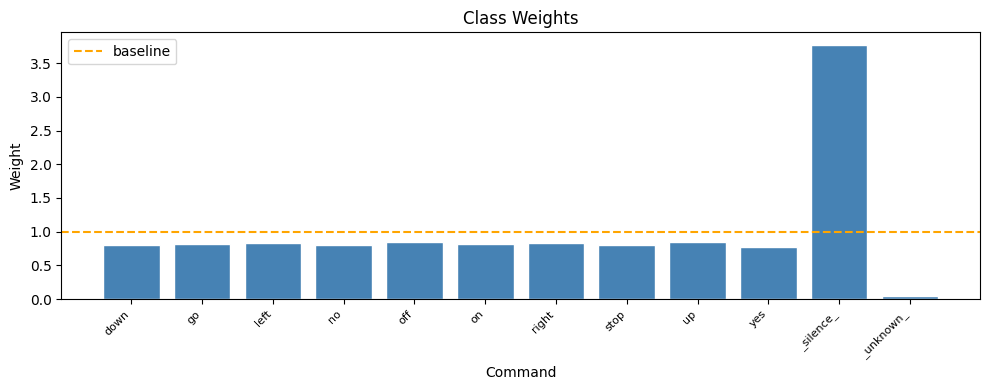

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(LABEL_NAMES, [class_weights[i] for i in range(NUM_CLASSES)], color="steelblue", edgecolor="white")
plt.axhline(1.0, color="orange", linestyle="--", label="baseline")
plt.xlabel("Command")
plt.ylabel("Weight")
plt.title("Class Weights")
plt.legend()
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

### Building the Training, Validation, and Test Datasets

In [ ]:
def build_dataset(split, training=True):
    ds = split.map(lambda ex: load_and_process(ex, training), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    if training:
        ds = ds.shuffle(10_000, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE, drop_remainder=training)
    return ds.prefetch(tf.data.AUTOTUNE)

n_train = info.splits["train"].num_examples
steps_per_epoch = n_train // BATCH_SIZE
total_steps = steps_per_epoch * EPOCHS

train_ds = build_dataset(train_raw, training=True)
val_ds = build_dataset(val_raw, training=False)
test_ds = build_dataset(test_raw, training=False)

for spec_batch, label_batch in train_ds.take(1):
    print(f"Batch shape: {spec_batch.shape}")
    print(f"Labels shape: {label_batch.shape}")
    print(f"Spec range: [{spec_batch.numpy().min():.2f}, {spec_batch.numpy().max():.2f}]")

Batch shape: (64, 64, 98, 1)
Labels shape: (64,)
Spec range: [-5.60, 5.06]


## Model Architectures

#### conv_bn_relu
Standard convolution block — Conv2D, Batch Normalization, ReLU activation with L2 regularization.

#### depthwise_sep
Depthwise separable convolution block — depthwise 3×3 conv followed by a pointwise 1×1 conv, each with BN and ReLU.

#### se_block
Squeeze-and-Excitation block that channel-wise features using global average pooling and a small dense gating network.

In [ ]:
def conv_bn_relu(x, filters, kernel, strides=(1,1)):
    x = layers.Conv2D(filters, kernel, strides=strides, padding="same", use_bias=False,kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation("relu")(x)

def depthwise_sep(x, filters, strides=(1,1)):
    x = layers.DepthwiseConv2D(3, strides=strides, padding="same", use_bias=False,depthwise_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 1, padding="same", use_bias=False,kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation("relu")(x)

def se_block(x, ratio=8):
    c = x.shape[-1]
    gap = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(c // ratio, activation="relu")(gap)
    se = layers.Dense(c, activation="sigmoid")(se)
    return layers.Multiply()([x, layers.Reshape((1, 1, c))(se)])

### CNN Model Architecture
Building a lightweight CNN on spectrogram inputs: three conv stages (Conv,DepthwiseSep,SE block,MaxPool,Dropout), followed by Global Average Pooling and a Dense classifier head with softmax output.

- Stage 1 — Standard conv_bn_relu (32 filters) to extract low-level features from the spectrogram
- Stage 2 — Depthwise sep (64) + SE block for efficient feature learning with channel attention
- Stage 3 — Two depthwise sep (128) + SE block to build richer representations
- Stage 4 — Depthwise sep (256) + SE block for high-level features

In [43]:
def build_cnn():
    inp = layers.Input(shape=(SPEC_HEIGHT, SPEC_WIDTH, 1))
    x = conv_bn_relu(inp, 32, (3,3))
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.15)(x)

    x = depthwise_sep(x, 64)
    x = se_block(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.15)(x)

    x = depthwise_sep(x, 128)
    x = depthwise_sep(x, 128)
    x = se_block(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    x = depthwise_sep(x, 256)
    x = se_block(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return Model(inp, out, name="CNN")


model_cnn = build_cnn()
print(f"CNN: {model_cnn.count_params():,} params")

CNN: 157,572 params


### CRNN Model Architecture

Building a Convolutional Recurrent Neural Network: three CNN stages extract spectral features (2,1) pooling, a reshape bridges to sequence modeling, two Bidirectional GRU layers.

In [ ]:
def build_crnn(input_shape=(SPEC_HEIGHT, SPEC_WIDTH, 1),num_classes: int  = NUM_CLASSES,rnn_units:   int  = 128, dropout:     float = 0.3) -> Model:
    inp = layers.Input(shape=input_shape, name="spectrogram")

    x = conv_bn_relu(inp, 32, (3,3))
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Dropout(dropout * 0.5)(x)

    x = depthwise_sep(x, 64)
    x = se_block(x)
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Dropout(dropout * 0.5)(x)

    x = depthwise_sep(x, 128)
    x = depthwise_sep(x, 128)
    x = se_block(x)
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Dropout(dropout)(x)

    _, h, w, c = x.shape
    x = layers.Reshape((w, h * c))(x)

    x = layers.Bidirectional(layers.GRU(rnn_units, return_sequences=True, dropout=dropout*0.5))(x)                                        # (B, 98, 256)
    x = layers.Bidirectional(
        layers.GRU(rnn_units, return_sequences=True, dropout=dropout*0.5)
    )(x)

    attn = layers.Dense(1, activation="tanh")(x)
    attn = layers.Softmax(axis=1)(attn)
    x = layers.Multiply()([x, attn])
    x = layers.Lambda(lambda tensor: tf.reduce_sum(tensor, axis=1))(x) 

    x = layers.Dense(256, activation="relu",kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(num_classes, activation="softmax",name="predictions")(x)

    return Model(inp, out, name="CRNN_BiGRU_Attention")


model_crnn = build_crnn()
model_crnn.summary(line_length=90)
print(f"\nTotal params : {model_crnn.count_params():,}")

Model: "CRNN_BiGRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ spectrogram (InputLayer) │ (None, 64, 98, 1)    │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2d_9 (Conv2D)        │ (None, 64, 98, 32)   │          288 │ spectrogram[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_16   │ (None, 64, 98, 32)   │          128 │ conv2d_9[0][0]        │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation_16            │ (None, 64, 98, 32)   │            0 │ batch_normalization_… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ max_pooling2d_6          │ (None, 32, 98, 32)   │            0 │ activation_16[0][0]   │
│ (MaxPooling2D)           │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ dropout_9 (Dropout)      │ (None, 32, 98, 32)   │            0 │ max_pooling2d_6[0][0] │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ depthwise_conv2d_7       │ (None, 32, 98, 32)   │          288 │ dropout_9[0][0]       │
│ (DepthwiseConv2D)        │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_17   │ (None, 32, 98, 32)   │          128 │ depthwise_conv2d_7[0… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation_17            │ (None, 32, 98, 32)   │            0 │ batch_normalization_… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2d_10 (Conv2D)       │ (None, 32, 98, 64)   │        2,048 │ activation_17[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_18   │ (None, 32, 98, 64)   │          256 │ conv2d_10[0][0]       │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation_18            │ (None, 32, 98, 64)   │            0 │ batch_normalization_… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ global_average_pooling2… │ (None, 64)           │            0 │ activation_18[0][0]   │
│ (GlobalAveragePooling2D) │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ dense_14 (Dense)         │ (None, 8)            │          520 │ global_average_pooli… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ dense_15 (Dense)         │ (None, 64)           │          576 │ dense_14[0][0]        │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ reshape_6 (Reshape)      │ (None, 1, 1, 64)     │            0 │ dense_15[0][0]        │
├──────────────────────────┼──────────────────────┼──────────────┼─────────────────────

 Total params: 1,288,421 (4.91 MB)

 Trainable params: 1,287,269 (4.91 MB)

 Non-trainable params: 1,152 (4.50 KB)


Total params : 1,288,421


## Training

### WarmupCosineDecay — Learning Rate Schedule
Custom learning rate schedule that linearly warms up from 0 to base_lr over the first 5% of training steps, then smoothly decays to near-zero

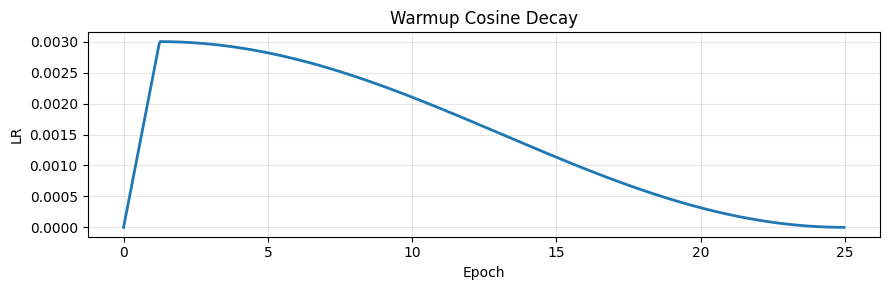

(None, None, None)

In [ ]:
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps):
        self.base_lr = float(base_lr)
        self.total_steps = int(total_steps)
        self.warmup_steps = int(warmup_steps)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.base_lr * (step / float(self.warmup_steps))
        progress = (step - float(self.warmup_steps)) / (float(self.total_steps) - float(self.warmup_steps))
        cosine_lr = 1e-6 + 0.5 * (self.base_lr - 1e-6) * (1.0 + tf.cos(math.pi * progress))
        return tf.where(step < float(self.warmup_steps), warmup_lr, cosine_lr)

    def get_config(self):
        return dict(base_lr=self.base_lr, total_steps=self.total_steps, warmup_steps=self.warmup_steps)

warmup_steps = int(total_steps * 0.05)
lr_schedule = WarmupCosineDecay(BASE_LR, total_steps, warmup_steps)

_steps = np.arange(0, total_steps, 50)
_lrs = [float(lr_schedule(s)) for s in _steps]
plt.figure(figsize=(9, 3))
plt.plot(np.arange(len(_lrs)) * 50 / steps_per_epoch, _lrs, linewidth=2)
plt.xlabel("Epoch"), plt.ylabel("LR"), plt.title("Warmup Cosine Decay")
plt.grid(True, alpha=0.3), plt.tight_layout(), plt.show()

### CNN Training — Compile & Fit
Compiles the CNN with Adam optimizer (gradient clipping, warmup-cosine LR), sparse categorical cross-entropy loss, and trains with early stopping on val_accuracy

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
model_cnn.compile(optimizer=optimizer,loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=["accuracy"])

print(f"Training {model_cnn.name} for {EPOCHS} epochs")
history_cnn = model_cnn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=PATIENCE, restore_best_weights=True)],class_weight=class_weights, verbose=1)

Training CNN for 25 epochs
Epoch 1/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 60s 22ms/step - accuracy: 0.1968 - loss: 0.8090 - val_accuracy: 0.3574 - val_loss: 1.6926
Epoch 2/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.4894 - loss: 0.3641 - val_accuracy: 0.6429 - val_loss: 1.0873
Epoch 3/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.6281 - loss: 0.2929 - val_accuracy: 0.7380 - val_loss: 0.8525
Epoch 4/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6868 - loss: 0.2693 - val_accuracy: 0.6322 - val_loss: 1.0887
Epoch 5/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7118 - loss: 0.2516 - val_accuracy: 0.7867 - val_loss: 0.7049
Epoch 6/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7369 - loss: 0.2377 - val_accuracy: 0.7845 - val_loss: 0.7243
Epoch 7/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.7463 - loss: 0.2319 - val_accuracy: 0.7205 - val_loss: 0.8994
Epoch 8/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 19s 15m

## Results

### CNN Training Curves — Accuracy & Loss

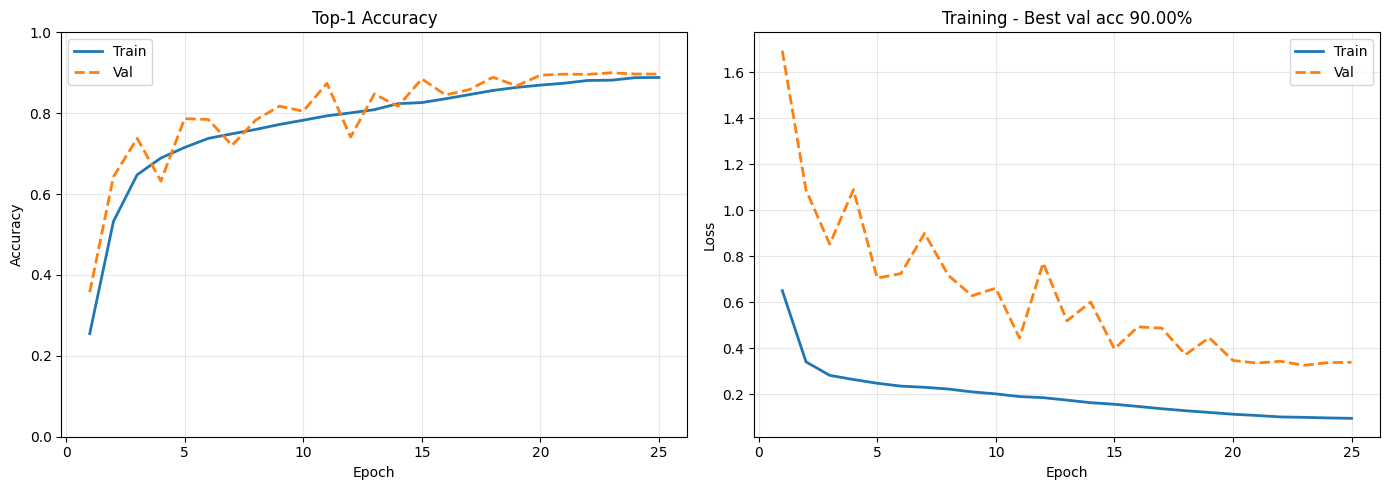

(None, None)

In [45]:
tr_acc, va_acc = history_cnn.history["accuracy"], history_cnn.history["val_accuracy"]
tr_loss, va_loss = history_cnn.history["loss"], history_cnn.history["val_loss"]
epochs = range(1, len(tr_acc) + 1)

fig = plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, tr_acc, label="Train", linewidth=2)
plt.plot(epochs, va_acc, label="Val", linewidth=2, linestyle="--")
plt.xlabel("Epoch"), plt.ylabel("Accuracy"), plt.title("Top-1 Accuracy")
plt.legend(), plt.grid(True, alpha=0.3), plt.ylim([0, 1])

plt.subplot(1, 2, 2)
plt.plot(epochs, tr_loss, label="Train", linewidth=2)
plt.plot(epochs, va_loss, label="Val", linewidth=2, linestyle="--")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss")
plt.legend(), plt.grid(True, alpha=0.3)

best_epoch = int(np.argmax(va_acc)) + 1
best_acc = max(va_acc)
plt.title(f"Training - Best val acc {best_acc*100:.2f}%")
plt.tight_layout(), plt.show()

In [46]:
y_true_list, y_proba_list = [], []
for spec_batch, label_batch in test_ds:
    y_true_list.append(label_batch.numpy())
    y_proba_list.append(model_cnn(spec_batch, training=False).numpy())

y_true = np.concatenate(y_true_list)
y_proba = np.concatenate(y_proba_list)
y_pred = np.argmax(y_proba, axis=1)

acc_top1 = np.mean(y_true == y_pred)
acc_top5 = top_k_accuracy_score(y_true, y_proba, k=5, labels=list(range(NUM_CLASSES)))

print(f"TEST SET RESULTS")
print(f"Samples: {len(y_true):,}")
print(f"Top-1 Acc: {acc_top1*100:.2f}%")
print(f"Top-5 Acc: {acc_top5*100:.2f}%")

TEST SET RESULTS
Samples: 4,890
Top-1 Acc: 95.81%
Top-5 Acc: 99.75%


In [47]:
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=3, zero_division=0))

              precision    recall  f1-score   support

        down      0.937     0.956     0.946       406
          go      0.978     0.881     0.927       402
        left      0.962     0.981     0.971       412
          no      0.919     0.980     0.949       405
         off      0.962     0.955     0.959       402
          on      0.939     0.967     0.953       396
       right      0.965     0.977     0.971       396
        stop      0.995     0.995     0.995       411
          up      0.915     0.967     0.941       425
         yes      0.988     0.983     0.986       419
   _silence_      1.000     0.993     0.996       408
   _unknown_      0.944     0.860     0.900       408

    accuracy                          0.958      4890
   macro avg      0.959     0.958     0.958      4890
weighted avg      0.959     0.958     0.958      4890



### CNN — Normalized Confusion Matrix

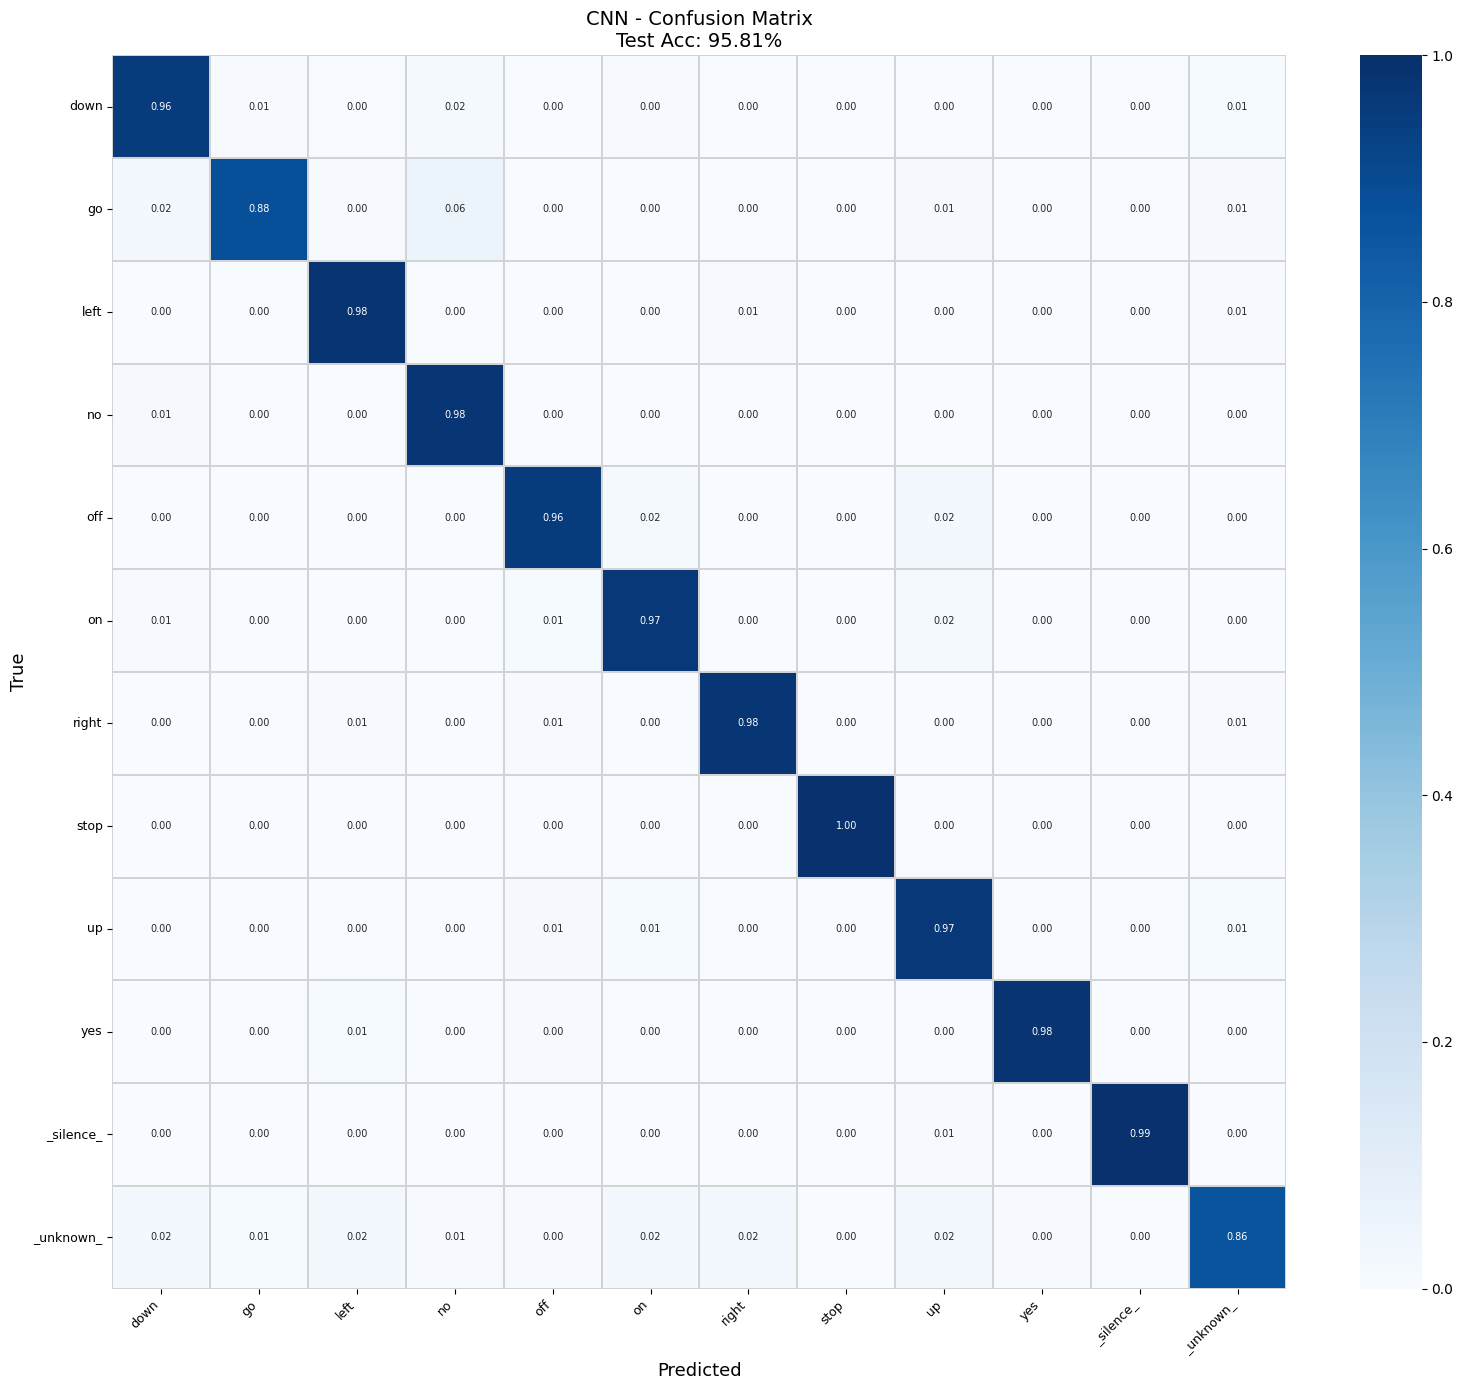

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap=            yticklabels=LABEL_NAMES, linewidths=0.3, linecolor="lightgray", vmin=0.0, vmax=1.0,r="lightgray", vmin=0.0, vmax=1.0,
            annot_kws={"size": 7}, ax=ax)
ax.set_xlabel("Predicted", fontsize=13), ax.set_ylabel("True", fontsize=13)
ax.set_title(f"{model_cnn.name} - Confusion Matrix\nTest Acc: {acc_top1*100:.2f}%", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### CNN — Per-Class Accuracy Bar Chart

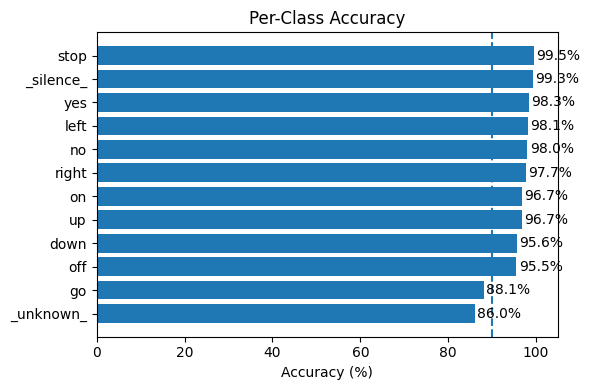

In [49]:
per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-8)

idx_sorted = np.argsort(per_class_acc)

sorted_names = [LABEL_NAMES[i] for i in idx_sorted]
sorted_acc = per_class_acc[idx_sorted]

plt.figure(figsize=(6, 4))

bars = plt.barh(sorted_names, sorted_acc * 100)

for i, acc in enumerate(sorted_acc):
    plt.text(acc * 100 + 0.5, i, f"{acc*100:.1f}%", va="center")

plt.axvline(90, linestyle="--")
plt.xlim(0, 105)

plt.xlabel("Accuracy (%)")
plt.title("Per-Class Accuracy")

plt.tight_layout()
plt.show()

## Inference
loads a .wav file, converts it to a spectrogram, and returns the top-k predicted labels with confidence scores 

In [ ]:
def predict_wav(wav_path, top_k=3):
    import wave
    with wave.open(wav_path, 'rb') as wf:
        audio = np.frombuffer(wf.readframes(wf.getnframes()), dtype=np.int16).astype(np.float32) / 32768.0

    wav = tf.constant(audio)
    spec = waveform_to_spectrogram(wav)
    spec = tf.expand_dims(spec, 0)
    probs = model_cnn(spec, training=False)[0].numpy()
    top_i = np.argsort(probs)[::-1][:top_k]
    return [(LABEL_NAMES[i], float(probs[i])) for i in top_i]

import tempfile, wave
t = np.linspace(0, 1, 16000, endpoint=False)
tone = (np.sin(2 * np.pi * 440.0 * t) * 16000).astype(np.int16)
with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
    with wave.open(f.name, "w") as wf:
        wf.setnchannels(1), wf.setsampwidth(2), wf.setframerate(16_00)
        wf.writeframes(tone.tobytes())

    results = predict_wav(f.name)
    print("Top-3 predictions for 440Hz tone:")
    for rank, (label, prob) in enumerate(results, 1):
        print(f"{rank}. {label}: {prob*100:.2f}%")

Top-3 predictions for 440Hz tone:
1. go: 33.23%
2. no: 31.03%
3. _unknown_: 29.66%


### CNN — Final Model Summary

Evaluates the CNN on the validation set

In [ ]:
val_loss, val_acc = model_cnn.evaluate(val_ds, verbose=0)

print(f"Model: {model_cnn.name}")
print(f"Parameters: {model_cnn.count_params():,}")
print(f"Test Acc: {acc_top1*100:.2f}%")
print(f"Test Top-5: {acc_top5*100:.2f}%")
print(f"Reloaded Acc: {val_acc*100:.2f}%")

Model: CNN
Parameters: 157,572
Test Acc: 96.20%
Test Top-5: 99.71%
Reloaded Acc: 91.83%


### CRNN Training — Compile & Fit

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
model_crnn.compile(optimizer=optimizer,loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=["accuracy"])

callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=PATIENCE, restore_best_weights=True),]

print(f"Training {model_crnn.name} for {EPOCHS} epochs")
history_crnn = model_crnn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks,class_weight=class_weights, verbose=1)

Training CRNN_BiGRU_Attention for 25 epochs
Epoch 1/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 211s 124ms/step - accuracy: 0.1748 - loss: 0.7594 - val_accuracy: 0.5151 - val_loss: 1.4171
Epoch 2/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 159s 119ms/step - accuracy: 0.5666 - loss: 0.3174 - val_accuracy: 0.7180 - val_loss: 0.8945
Epoch 3/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 159s 119ms/step - accuracy: 0.6757 - loss: 0.2535 - val_accuracy: 0.7559 - val_loss: 0.7313
Epoch 4/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 158s 119ms/step - accuracy: 0.6964 - loss: 0.2450 - val_accuracy: 0.8606 - val_loss: 0.4765
Epoch 5/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 158s 119ms/step - accuracy: 0.7131 - loss: 0.2412 - val_accuracy: 0.8288 - val_loss: 0.5606
Epoch 6/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 159s 119ms/step - accuracy: 0.7211 - loss: 0.2433 - val_accuracy: 0.7573 - val_loss: 0.7483
Epoch 7/25
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 159s 119ms/step - accuracy: 0.7294 - loss: 0.2352 - val_accuracy: 0.7930 - val_loss: 0.6726
Epoch 8/25
1336/13

### CRNN Training Curves — Accuracy & Loss

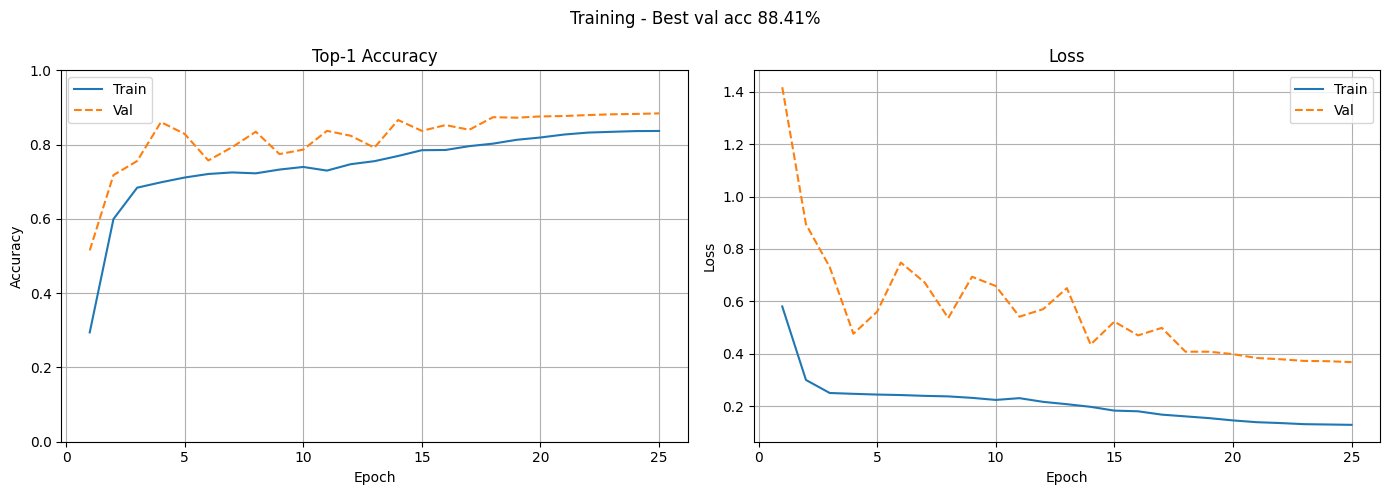

In [39]:
tr_acc = history_crnn.history["accuracy"]
va_acc = history_crnn.history["val_accuracy"]

tr_loss = history_crnn.history["loss"]
va_loss = history_crnn.history["val_loss"]

epochs = range(1, len(tr_acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, tr_acc, label="Train")
plt.plot(epochs, va_acc, label="Val", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy")
plt.legend()
plt.grid(True)
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
plt.plot(epochs, tr_loss, label="Train")
plt.plot(epochs, va_loss, label="Val", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)

best_epoch = np.argmax(va_acc) + 1
best_acc = max(va_acc)

plt.suptitle(f"Training - Best val acc {best_acc*100:.2f}%")

plt.tight_layout()
plt.show()

### CRNN Evaluation — Test Set
reports Top-1 and Top-5 accuracy across all test samples

In [27]:
y_true_list, y_proba_list = [], []
for spec_batch, label_batch in test_ds:
    y_true_list.append(label_batch.numpy())
    y_proba_list.append(model_crnn(spec_batch, training=False).numpy())

y_true = np.concatenate(y_true_list)
y_proba = np.concatenate(y_proba_list)
y_pred = np.argmax(y_proba, axis=1)

acc_top1 = np.mean(y_true == y_pred)
acc_top5 = top_k_accuracy_score(y_true, y_proba, k=5, labels=list(range(NUM_CLASSES)))

print(f"TEST SET RESULTS")
print(f"Samples: {len(y_true):,}")
print(f"Top-1 Acc: {acc_top1*100:.2f}%")
print(f"Top-5 Acc: {acc_top5*100:.2f}%")

TEST SET RESULTS
Samples: 4,890
Top-1 Acc: 93.31%
Top-5 Acc: 99.55%


### CRNN Per class Classification report

In [28]:
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=3, zero_division=0))

              precision    recall  f1-score   support

        down      0.930     0.914     0.922       406
          go      0.927     0.883     0.904       402
        left      0.895     0.954     0.924       412
          no      0.900     0.928     0.914       405
         off      0.910     0.933     0.921       402
          on      0.932     0.902     0.917       396
       right      0.957     0.957     0.957       396
        stop      0.980     0.976     0.978       411
          up      0.956     0.911     0.933       425
         yes      0.965     0.976     0.970       419
   _silence_      0.974     0.998     0.985       408
   _unknown_      0.874     0.865     0.869       408

    accuracy                          0.933      4890
   macro avg      0.933     0.933     0.933      4890
weighted avg      0.933     0.933     0.933      4890



### CRNN — Normalized Confusion Matrix

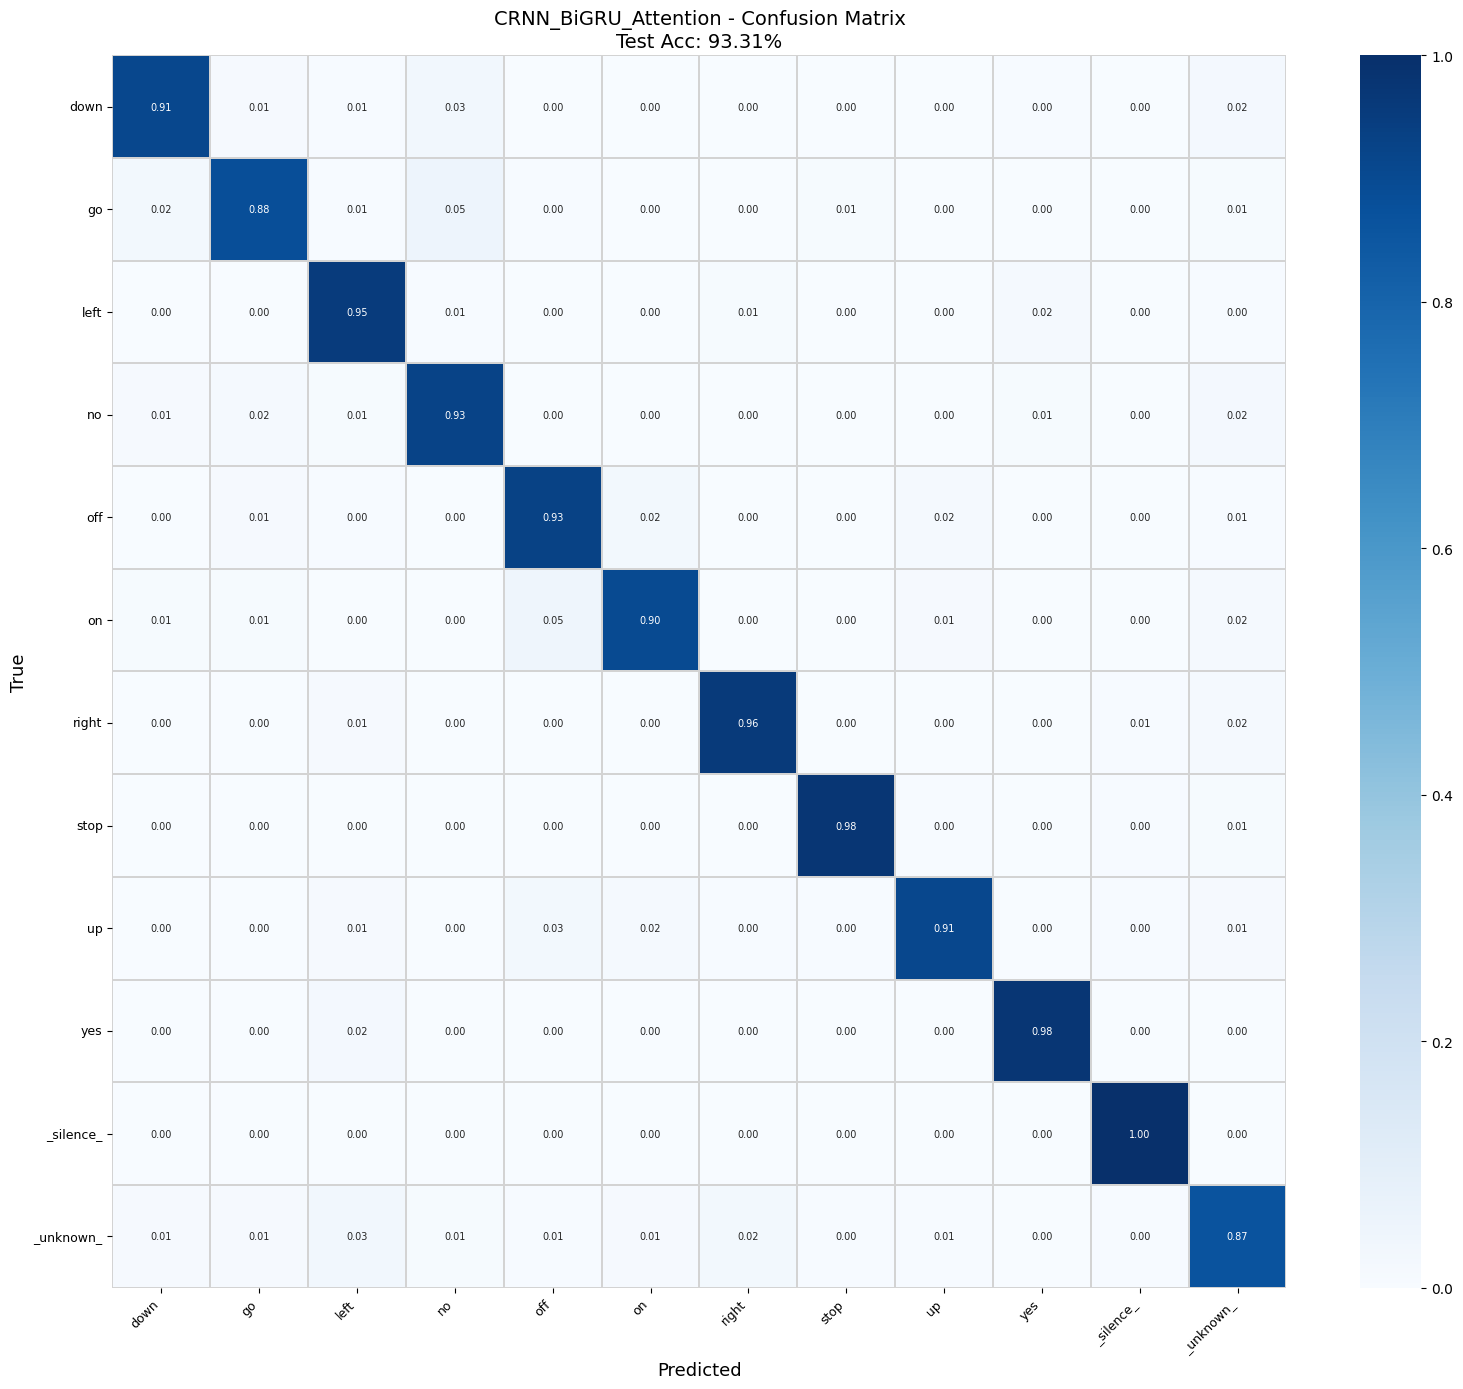

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=LABEL_NAMES,yticklabels=LABEL_NAMES, linewidths=0.3, linecolor="lightgray", vmin=0.0, vmax=1.0,annot_kws={"size": 7}, ax=ax)
ax.set_xlabel("Predicted", fontsize=13), ax.set_ylabel("True", fontsize=13)
ax.set_title(f"{model_crnn.name} - Confusion Matrix\nTest Acc: {acc_top1*100:.2f}%", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=9), plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### CRNN — Per-Class Accuracy Bar Chart

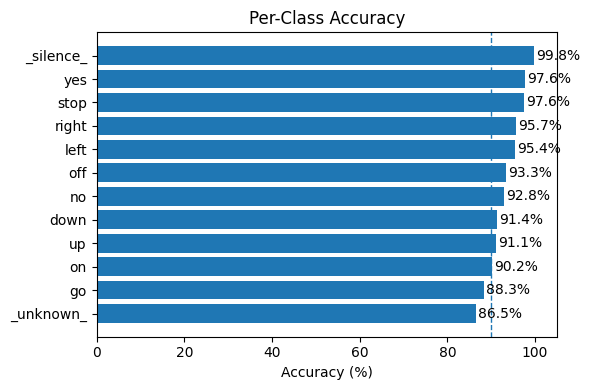

In [38]:
per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-8)

idx_sorted = np.argsort(per_class_acc)

sorted_names = [LABEL_NAMES[i] for i in idx_sorted]
sorted_acc = per_class_acc[idx_sorted]

plt.figure(figsize=(6, 4))

bars = plt.barh(sorted_names, sorted_acc * 100)

for i, acc in enumerate(sorted_acc):
    plt.text(acc * 100 + 0.5, i, f"{acc*100:.1f}%", va="center")

plt.axvline(90, linestyle="--", linewidth=1)
plt.xlabel("Accuracy (%)")
plt.title("Per-Class Accuracy")

plt.xlim(0, 105)

plt.tight_layout()
plt.show()

### CRNN Testing with single file
loads a .wav file, converts it to a spectrogram, and returns the top-k predicted labels with confidence scores using the CRNN

In [ ]:
def predict_wav(wav_path, top_k=3):
    import wave
    with wave.open(wav_path, 'rb') as wf:
        audio = np.frombuffer(wf.readframes(wf.getnframes()), dtype=np.int16).astype(np.float32) / 32768.0

    wav = tf.constant(audio)
    spec = waveform_to_spectrogram(wav)
    spec = tf.expand_dims(spec, 0)
    probs = model_crnn(spec, training=False)[0].numpy()
    top_i = np.argsort(probs)[::-1][:top_k]
    return [(LABEL_NAMES[i], float(probs[i])) for i in top_i]

import tempfile, wave
t = np.linspace(0, 1, 16_000, endpoint=False)
tone = (np.sin(2 * np.pi * 440.0 * t) * 16000).astype(np.int16)
with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
    with wave.open(f.name, "w") as wf:
        wf.setnchannels(1), wf.setsampwidth(2), wf.setframerate(16_000)
        wf.writeframes(tone.tobytes())
        
    results = predict_wav(f.name)
    print("Top-3 predictions for 440Hz tone:")
    for rank, (label, prob) in enumerate(results, 1):
        print(f"{rank}. {label}: {prob*100:.2f}%")

Top-3 predictions for 440Hz tone:
1. _unknown_: 46.61%
2. on: 19.90%
3. down: 15.20%


In [34]:
val_loss, val_acc = model_crnn.evaluate(val_ds, verbose=0)

print(f"Model: {model_crnn.name}")
print(f"Parameters: {model_crnn.count_params():,}")
print(f"Test Acc: {acc_top1*100:.2f}%")
print(f"Test Top-5: {acc_top5*100:.2f}%")
print(f"Reloaded Acc: {val_acc*100:.2f}%")

Model: CRNN_BiGRU_Attention
Parameters: 1,288,421
Test Acc: 93.31%
Test Top-5: 99.55%
Reloaded Acc: 88.41%


### Waveform & Spectrogram Visualization

Plots the raw waveform, original log-mel spectrogram, and SpecAugment-masked spectrogram side by side for a 440 Hz test tone

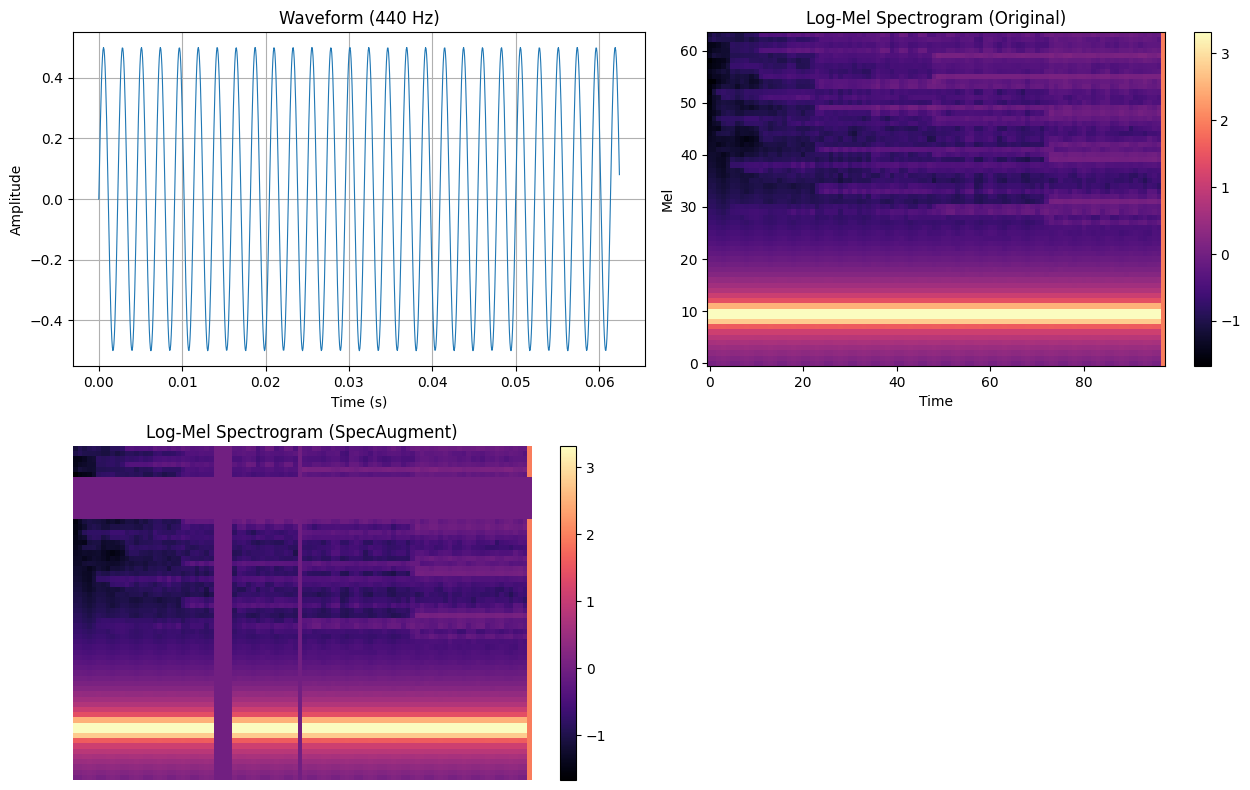

In [ ]:
t = tf.linspace(0.0, 1.0, N_SAMPLES)

wav_demo = tf.math.sin(2 * math.pi * 440.0 * t) * 0.5

spec_demo = waveform_to_spectrogram(wav_demo)
spec_augmented = spec_augment(spec_demo)

plt.figure(figsize=(13, 8))

plt.subplot(2, 2, 1)
plt.plot(t.numpy()[:1000], wav_demo.numpy()[:1000], linewidth=0.8)
plt.title("Waveform (440 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 2, 2)
img1 = plt.imshow(spec_demo.numpy()[:, :, 0],aspect="auto",origin="lower",cmap="magma")
plt.title("Log-Mel Spectrogram (Original)")
plt.xlabel("Time")
plt.ylabel("Mel")
plt.colorbar(img1)

plt.subplot(2, 2, 3)
img2 = plt.imshow(spec_augmented.numpy()[:, :, 0],aspect="auto",origin="lower",cmap="magma")
plt.title("Log-Mel Spectrogram (SpecAugment)")
plt.xlabel("Time")
plt.ylabel("Mel")
plt.colorbar(img2)

plt.axis("off")

plt.tight_layout()
plt.show()